
**Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

**Edición 2023**

---
## Trabajo práctico entregable - Parte 1

In [1]:
import io
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_context('talk')

/home/ruben/.local/lib/python3.8/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## Lectura del dataset

En la notebook 00 se explican los detalles de la siguiente sección.

In [2]:
url = 'https://raw.githubusercontent.com/DiploDatos/AnalisisyVisualizacion/master/sysarmy_survey_2022_processed.csv'
df = pd.read_csv(url)

In [3]:
df.head(5)

,work_country,work_province,work_dedication,work_contract_type,salary_monthly_BRUTO,salary_monthly_NETO,numero,salary_in_usd,salary_last_dollar_value,salary_pay_cripto,...,profile_studies_level_state,profile_career,profile_university,profile_boot_camp,profile_boot_camp_carrer,work_on_call_duty,salary_on_call_duty_charge,work_on_call_duty_charge_type,profile_age,profile_gender
0,Argentina,Catamarca,Full-Time,Staff (planta permanente),300000.0,245000.0,True,NaN,NaN,NaN,...,Completo,Licenciatura en redes y comunicación de datos,UP - Universidad de Palermo,NaN,NaN,NaN,NaN,NaN,35,Varón Cis
1,Argentina,Chaco,Full-Time,Remoto (empresa de otro país),900000.0,850000.0,True,Cobro todo el salario en dólares,300,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31,Varón Cis
2,Argentina,Chaco,Full-Time,Staff (planta permanente),120000.0,115000.0,True,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27,Varón Cis
3,Argentina,Chaco,Full-Time,Remoto (empresa de otro país),440000.0,0.0,True,Cobro todo el salario en dólares,220,Cobro todo el salario criptomonedas,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21,Varón Cis
4,Argentina,Chaco,Full-Time,Staff (planta permanente),140000.0,125000.0,True,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32,Varón Cis


Primero listamos todas los nombres de las columnas para identificar las columnas que analizaremos.

In [4]:
df.columns

Index(['work_country', 'work_province', 'work_dedication',
       'work_contract_type', 'salary_monthly_BRUTO', 'salary_monthly_NETO',
       'numero', 'salary_in_usd', 'salary_last_dollar_value',
       'salary_pay_cripto', 'salary_%_cripto', 'salary_has_bonus',
       'salary_bonus_tied_to', 'salary_inflation_adjustment',
       'salary_percentage_inflation_adjustment',
       'salary_month_last_inflation_adjustment',
       'salary_comparison_last_semester', 'salary_benefit',
       'salary_satisfaction', 'Trabajo de', 'profile_years_experience',
       'work_years_in_company', 'work_years_in_current_position',
       'work_people_in_charge_of', 'tools_platform',
       'tools_programming_languages', 'tools_frameworks', 'tools_data_bases',
       'tools_qa_testing', 'company_employee_number', 'work_work_modality',
       'Si trabajas bajo un esquema híbrido ¿Cuántos días a la semana vas a la oficina?',
       'company_recommended', 'profile_studies_level',
       'profile_studies_le

# Ejercicio 1 - Análisis descriptivo

Responder a la pregunta: **¿Cuáles son los lenguajes de programación asociados a los mejores salarios?**

Para ello:
1. Seleccionar las columnas relevantes para analizar.
2. Seleccionar las filas relevantes para analizar. Esto incluye la eliminación de valores extremos y erróneos, pero también puede enfocar el análisis en una sub-población. Por ejemplo, se pueden limitar a personas con un salario mayor que 10000 pesos, o a las personas que trabajan sólo en "Data Science", pero deben justificar su elección y reformular la pregunta inicial de ser necesario.
  * Obtener una lista de los lenguajes de programación más populares. Decidir cuántos y cuáles seleccionan para incluir en el análisis.
  * Para cada una de las otras columnas del punto anterior, elegir los rangos o valores seleccionan para incluir en el análisis.
3. Seleccionar métricas que ayuden a responder la pregunta, y los métodos para analizarlas. Elegir UNA de las siguientes opciones:
  * Comparar las distribuciones de salario para cada lenguaje utilizando visualizaciones. Como la visualización es el producto final, debe ser clara y mostrar información relevante.
  * Comparar medidas de estadística descriptiva sobre la distribución de salario para cada lenguaje. Sean creativos, la estadística descriptiva nos permite decir cosas como: "el 10% de los mejores sueldos los ganan, en su mayoría, programadores que saben kotlin!" (donde *mayoría* es un término medio engañoso que sólo significa más del 50%). Para comparar múltiples lenguajes, les recomendamos usar también visualizaciones.
  * Comparar probabilidades. Por ejemplo: "Si sabés Python o Java, tenés un 30% más de chances de ganar arriba de 100K".

Si lo consideran necesario, realicen varias iteraciones. Es decir, si encuentran que las distribuciones de los lenguajes de programación que seleccionaron inicialmente no son muy diferentes, pueden re-hacer el análisis usando sólo los lenguajes de programación que son diferentes.

Guardamos en una  lista los nombres de las columnas de interes. En particular, vamos a analizar los salarios y las distintas herramientas que utiliza cada programador.

Luego creamos un DataFrame nuevo cuyas columnas son las que queremos analizar.

In [5]:
relevant_columns = ['salary_monthly_BRUTO', 
                    'salary_monthly_NETO', 
                    'tools_programming_languages',
                    'tools_platform',
                    'tools_frameworks',
                    'tools_data_bases',
                    'tools_qa_testing'
                    ]
df_relevant = df[relevant_columns]

In [6]:
df_relevant

,salary_monthly_BRUTO,salary_monthly_NETO,tools_programming_languages,tools_platform,tools_frameworks,tools_data_bases,tools_qa_testing
0,300000.0,245000.0,Python,"Amazon Web Services, Linux, VMWare",Ninguno de los anteriores,ElasticSearch,"Postman, Visual Studio Coded UI"
1,900000.0,850000.0,"CSS, HTML, Java, Javascript, SQL, TypeScript",Amazon Web Services,React.js,PostgreSQL,Cypress
2,120000.0,115000.0,"Javascript, PHP, Python",Amazon Web Services,"Flask, Laravel, Vue.js",MariaDB,Ninguna de las anteriores
3,440000.0,0.0,"Javascript, TypeScript","Firebase, Serverless","Node.js, React.js","ElasticSearch, MongoDB",Ninguna de las anteriores
4,140000.0,125000.0,"CSS, HTML, Javascript",Amazon Web Services,React.js,MySQL,Ninguna de las anteriores
...,...,...,...,...,...,...,...
5353,311.7,214.8,Ninguno de los anteriores,Azure,Ninguno de los anteriores,Ninguna de las anteriores,Ninguna de las anteriores
5354,150000.0,93000.0,Ninguno de los anteriores,Ninguna de las anteriores,Ninguno de los anteriores,MySQL,Ninguna de las anteriores
5355,230000.0,190900.0,"HTML, SQL",N,SAP,"Microsoft SQL Server, MySQL","Postman, SoapUI"
5356,450989.0,297750.0,"Javascript, SQL","Amazon Web Services, Firebase, Google Cloud Pl...",Ninguno de los anteriores,"Microsoft SQL Server, MongoDB, MySQL, Oracle, ...",Postman


Primero buscamos valores faltantes o valores no numericos que puedan introducir ruidos en los calculos.

In [7]:
df_relevant[['salary_monthly_NETO','salary_monthly_BRUTO']].isna().sum()

salary_monthly_NETO     0
salary_monthly_BRUTO    0
dtype: int64

Nos preguntamos si es que los valores faltantes estan presentes en forma de valores nulos, es decir, si es que hay ceros.

In [8]:
len(df_relevant[df_relevant['salary_monthly_NETO'] == 0])

254

In [9]:
len(df_relevant[df_relevant['salary_monthly_BRUTO'] == 0])

14

Vemos que efectivamente hay valores nulos en ambas columnas de salario. Podemos preguntarnos que filas tienen ambos valores de salario nulos.

In [10]:
cond1 = df_relevant['salary_monthly_BRUTO'] == 0
cond2 = df_relevant['salary_monthly_NETO'] == 0
len(df_relevant.loc[cond1 & cond2])

6

In [11]:
df_relevant.loc[cond1 & cond2]

,salary_monthly_BRUTO,salary_monthly_NETO,tools_programming_languages,tools_platform,tools_frameworks,tools_data_bases,tools_qa_testing
2849,0.0,0.0,"Go, Javascript, PHP, TypeScript",Amazon Web Services,React.js,PostgreSQL,Jest
3786,0.0,0.0,"Java, Kotlin, SQL",Heroku,"Hibernate, Spring",MySQL,JUnit
3830,0.0,0.0,".NET, Clojure, HTML, Javascript, PHP, Python, SQL",Ninguna de las anteriores,".NET Core, Bootstrap, Laravel, Node.js",MySQL,Ninguna de las anteriores
4029,0.0,0.0,"Javascript, TypeScript",VMWare,Vue.js,"MongoDB, MySQL",Ninguna de las anteriores
4159,0.0,0.0,"Java, SQL",Amazon Web Services,"Hibernate, Spring","Amazon DynamoDB, Amazon RDS/Aurora, MySQL","JUnit, Postman"
4637,0.0,0.0,Ninguno de los anteriores,Ninguna de las anteriores,Ninguno de los anteriores,Ninguna de las anteriores,Ninguna de las anteriores


Vemos que estas observaciones no dan informacion al analisis, por lo que pueden ser eliminadas.

In [12]:
df_relevant = df_relevant.drop(df_relevant.loc[cond1 & cond2].index, axis = 0)

Aun tenemos valores nulos en ambas columnas de salarios, solo que no de forma simultanea. Podemos usar este hecho para combinar ambas columnas y obtener una sola, donde en los casos en que el salario neto sea nulo, tomemos el valor el salario bruto.

In [13]:
df_relevant['salary'] = [x if x != 0 else y for x, y in zip(df_relevant['salary_monthly_NETO'], df_relevant['salary_monthly_BRUTO'])]

Hecho esto podemos eliminar las columnas de salario para evitar confusion.

In [14]:
df_relevant = df_relevant.drop(['salary_monthly_BRUTO', 'salary_monthly_NETO'], axis = 1)

In [15]:
df_relevant

,tools_programming_languages,tools_platform,tools_frameworks,tools_data_bases,tools_qa_testing,salary
0,Python,"Amazon Web Services, Linux, VMWare",Ninguno de los anteriores,ElasticSearch,"Postman, Visual Studio Coded UI",245000.0
1,"CSS, HTML, Java, Javascript, SQL, TypeScript",Amazon Web Services,React.js,PostgreSQL,Cypress,850000.0
2,"Javascript, PHP, Python",Amazon Web Services,"Flask, Laravel, Vue.js",MariaDB,Ninguna de las anteriores,115000.0
3,"Javascript, TypeScript","Firebase, Serverless","Node.js, React.js","ElasticSearch, MongoDB",Ninguna de las anteriores,440000.0
4,"CSS, HTML, Javascript",Amazon Web Services,React.js,MySQL,Ninguna de las anteriores,125000.0
...,...,...,...,...,...,...
5353,Ninguno de los anteriores,Azure,Ninguno de los anteriores,Ninguna de las anteriores,Ninguna de las anteriores,214.8
5354,Ninguno de los anteriores,Ninguna de las anteriores,Ninguno de los anteriores,MySQL,Ninguna de las anteriores,93000.0
5355,"HTML, SQL",N,SAP,"Microsoft SQL Server, MySQL","Postman, SoapUI",190900.0
5356,"Javascript, SQL","Amazon Web Services, Firebase, Google Cloud Pl...",Ninguno de los anteriores,"Microsoft SQL Server, MongoDB, MySQL, Oracle, ...",Postman,297750.0


Para poder hacer un analisis por encima de los salarios podemos ver los estadisticos principales.

In [16]:
df_relevant[['salary']].describe(percentiles=[0.1,0.5,0.9]).style.format('{:.0f}')

,salary
count,5352
mean,298456
std,414417
min,1
10%,74910
50%,211560
90%,563850
max,15000000


Los graficamos para tener una dea mas clara de la distribucion de salarios.

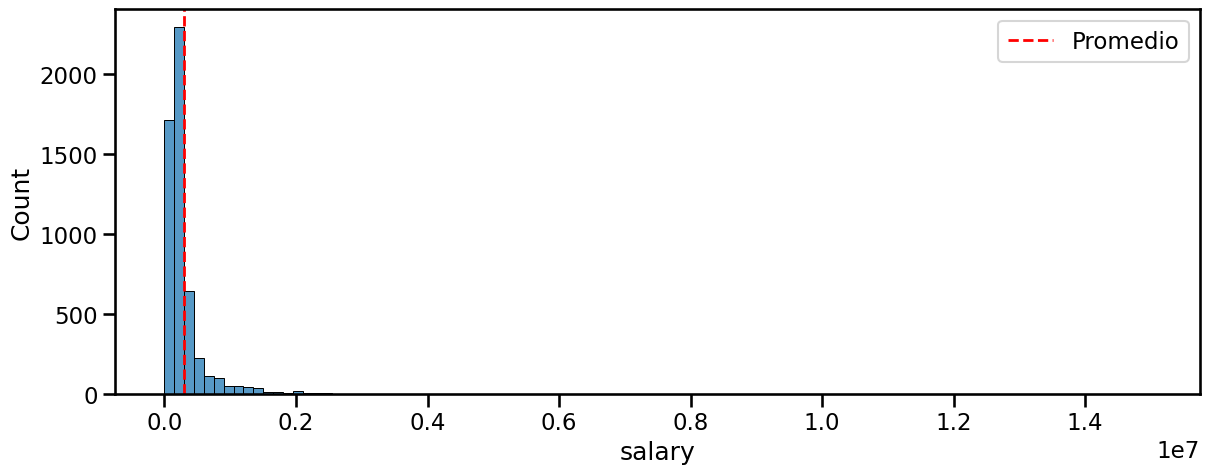

In [17]:
fig0, ax0 = plt.subplots(figsize=(14, 5))
sns.histplot(data=df_relevant, x=df_relevant['salary'],bins = 100 , ax=ax0)
plt.axvline(df_relevant['salary'].mean(), color='red', linestyle='--', linewidth=2, label='Promedio')
plt.legend()
plt.show()

Vemos que tenemos valores extremos muy grandes que pueden introducir ruidos en los estadisticos principales. Podemos crear una funcion que  identifique estos valores atipicos o "outliers" para poder eliminarlos.

In [18]:
def remove_outliers(df, column):

    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    filtered_df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

    return filtered_df

In [19]:
df_relevant = remove_outliers(df_relevant,'salary')

In [20]:
df_relevant.shape

(4816, 6)

Vemos que pasamos de tener un DataFrame de 5352 filas a uno de 4816. Es decir, eliminamos un 10% de los datos que teniamos originalmente.

Analizamos los estadisticos principales para ver como cambiaron.

In [21]:
df_relevant[['salary']].describe(percentiles=[0.1, 0.5, 0.9]).style.format('{:.0f}')

,salary
count,4816
mean,203749
std,117435
min,1
10%,67000
50%,198000
90%,360000
max,562500


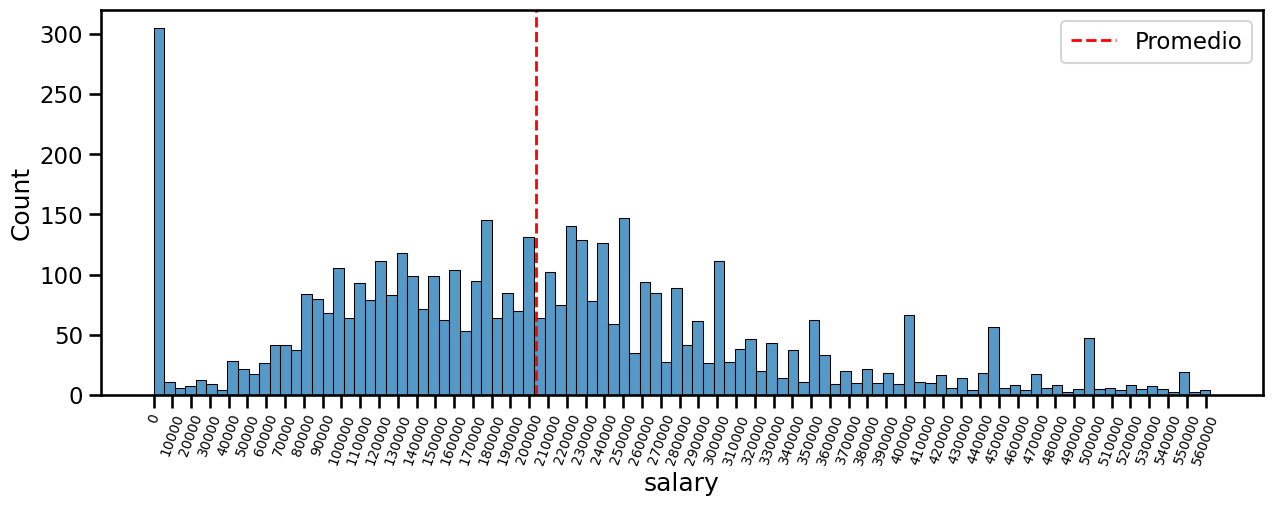

In [22]:
fig1, ax1 = plt.subplots(figsize=(15, 5))
sns.histplot(data=df_relevant, x=df_relevant['salary'],bins = 100 , ax=ax1)
plt.axvline(df_relevant['salary'].mean(), color='red', linestyle='--', linewidth=2, label='Promedio')
plt.xticks(range(int(df_relevant['salary'].min() - 1), int(df_relevant['salary'].max() + 1), 10000), rotation = 70, fontsize = 10)
plt.legend()
plt.show()

### Conteo de frecuencias de los lenguajes de programación

La columna que contiene información sobre los lenguajes de programación utilizados es `tools_programming_languages`. Sus valores son strings con los lenguajes seleccionados separados por comas.



In [23]:
df_relevant[['tools_programming_languages']]

,tools_programming_languages
0,Python
2,"Javascript, PHP, Python"
3,"Javascript, TypeScript"
4,"CSS, HTML, Javascript"
5,"Go, Java"
...,...
5353,Ninguno de los anteriores
5354,Ninguno de los anteriores
5355,"HTML, SQL"
5356,"Javascript, SQL"


Las siguientes celdas de código separan estos lenguajes de programación y cuentan la frecuencia con la que aparecen.

No es necesario entender este código en profundidad, aunque sí es un buen ejercicio.

In [24]:
#Esta funcion toma las cadenas de string de una columna, las separa en palabras,
#eliminando espacios y comas, y me devuelve listas cuyos elementos son las palabras
#que estaban en las cadenas de string.

def split_languages(languages_str):
  
  #Si el elemento no es un string, entonces la funcion devuelve una lista vacia
  if not isinstance(languages_str, str):
    return []
  
  #En el caso que el elemento si sea un string, hacemos las transformaciones neccesarias.
  #Primero eliminamos todas las mayusculas con la funcion "lower()"
  #Luego, si la string es "ninguno de los anteriores", lo reempleza por un espacio vacio
  #Si no encuentra este string, no hace nada.
  languages_str = languages_str.lower().replace('ninguno de los anteriores', '')

  #La funcion va a retornar una lista cuyos elementos son las palabras separadas por espacios (".split()")
  #Antes de guardar estos elementos usamos la funcion replace para eliminar las comas,
  #y la funcion strip() para eliminar los espacios antes y despues de cada palabra y que nos quede
  #la palabra limpia..
  return [lang.strip().replace(',', '') for lang in languages_str.split()]

In [25]:
df_relevant['cured_programming_languages'] = df_relevant['tools_programming_languages'].apply(split_languages)

/tmp/ipykernel_3773/362537545.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_relevant['cured_programming_languages'] = df_relevant['tools_programming_languages'].apply(split_languages)


In [27]:
df_relevant

,tools_programming_languages,tools_platform,tools_frameworks,tools_data_bases,tools_qa_testing,salary,cured_programming_languages
0,Python,"Amazon Web Services, Linux, VMWare",Ninguno de los anteriores,ElasticSearch,"Postman, Visual Studio Coded UI",245000.0,[python]
2,"Javascript, PHP, Python",Amazon Web Services,"Flask, Laravel, Vue.js",MariaDB,Ninguna de las anteriores,115000.0,"[javascript, php, python]"
3,"Javascript, TypeScript","Firebase, Serverless","Node.js, React.js","ElasticSearch, MongoDB",Ninguna de las anteriores,440000.0,"[javascript, typescript]"
4,"CSS, HTML, Javascript",Amazon Web Services,React.js,MySQL,Ninguna de las anteriores,125000.0,"[css, html, javascript]"
5,"Go, Java","Amazon Web Services, Docker, Firebase, Linux, ...",GinGonic,"Amazon DynamoDB, Amazon RDS/Aurora","Postman, Gingko",395000.0,"[go, java]"
...,...,...,...,...,...,...,...
5353,Ninguno de los anteriores,Azure,Ninguno de los anteriores,Ninguna de las anteriores,Ninguna de las anteriores,214.8,[]
5354,Ninguno de los anteriores,Ninguna de las anteriores,Ninguno de los anteriores,MySQL,Ninguna de las anteriores,93000.0,[]
5355,"HTML, SQL",N,SAP,"Microsoft SQL Server, MySQL","Postman, SoapUI",190900.0,"[html, sql]"
5356,"Javascript, SQL","Amazon Web Services, Firebase, Google Cloud Pl...",Ninguno de los anteriores,"Microsoft SQL Server, MongoDB, MySQL, Oracle, ...",Postman,297750.0,"[javascript, sql]"


In [26]:
df_relevant[['cured_programming_languages']]

,cured_programming_languages
0,[python]
2,"[javascript, php, python]"
3,"[javascript, typescript]"
4,"[css, html, javascript]"
5,"[go, java]"
...,...
5353,[]
5354,[]
5355,"[html, sql]"
5356,"[javascript, sql]"


In [28]:
df_lang_sal = df_relevant[['salary','cured_programming_languages']]
df_lang_sal

,salary,cured_programming_languages
0,245000.0,[python]
2,115000.0,"[javascript, php, python]"
3,440000.0,"[javascript, typescript]"
4,125000.0,"[css, html, javascript]"
5,395000.0,"[go, java]"
...,...,...
5353,214.8,[]
5354,93000.0,[]
5355,190900.0,"[html, sql]"
5356,297750.0,"[javascript, sql]"


In [29]:
#Para cada lenguaje que aparece en las listas, vamos a duplicar la fila correspondiente
# Vamos a crear un nuevo DataFrame donde estarán solo las columnas de interes, para simplificar el analisis.

df_lang_sal_expand = df_lang_sal['cured_programming_languages'].apply(pd.Series).stack()\
    .reset_index(level=-1, drop=True).to_frame()\
    .join(df_lang_sal)\
    .rename(columns={0: 'programming_language'})\
    .drop(['cured_programming_languages'], axis = 1)

/tmp/ipykernel_3773/2138431956.py:4: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  df_lang_sal_expand = df_lang_sal['cured_programming_languages'].apply(pd.Series).stack()\


In [30]:
df_lang_sal_expand

,programming_language,salary
0,python,245000.0
2,javascript,115000.0
2,php,115000.0
2,python,115000.0
3,javascript,440000.0
...,...,...
5352,sql,90000.0
5355,html,190900.0
5355,sql,190900.0
5356,javascript,297750.0


En la columna `programming_language` se encuentra cada lenguaje por separado. Notar que si una respuesta contenía 3 lenguajes, como `"HTML, Javascript, Python"`, la fila ha sido replicada 3 veces. Por ello, hay tres filas con índice 1.

Para saber la cantidad de programadores que utiliza cada lenguaje, podemos armar un DataFrame con las frecuencias de aparicion de cada lenguaje. 

In [31]:
language_count = df_lang_sal_expand['programming_language'].value_counts()\
    .reset_index()\
    .rename(columns={'index': 'language', 'programming_language': 'frequency'})

In [32]:
language_count

,language,frequency
0,sql,1905
1,javascript,1867
2,html,1410
3,python,1229
4,css,958
...,...,...
213,mails,1
214,usando,1
215,gestiono,1
216,pl/1,1


Supongamos que queremos ver que ocurre con los 10 lenguajes mas utilizados.

In [39]:
top_ten_lang = language_count.head(10)
top_ten_lang

,language,frequency
0,sql,1905
1,javascript,1867
2,html,1410
3,python,1229
4,css,958
5,java,871
6,typescript,795
7,bash/shell,754
8,.net,565
9,php,549


Una vez identificados los lenguajes de programacion mas utilizados podemos crear un nuevo DataFrame con las metricas estadisticas de interes para ver la  distribucion de salarios de cada uno.

In [45]:
language = [lang for lang in top_ten_lang['language'].unique()]
sal_prom = [df_lang_sal_expand.loc[df_lang_sal_expand['programming_language'] == lang ]['salary'].mean() for lang in language]

In [46]:
df_sal_prom = pd.DataFrame({
    'language' : language,
    'sal_prom' : sal_prom
})

In [47]:
df_sal_prom.sort_values('sal_prom', ascending = False)

,language,sal_prom
3,python,233058.108736
7,bash/shell,223439.137918
5,java,221263.250459
8,.net,217143.980690
6,typescript,208063.599665
9,php,206722.975592
1,javascript,205839.335096
0,sql,205476.090204
2,html,196814.032957
4,css,191111.155628


Podemos observar que, de todos los lenguajes, python es el que mejor sueldo tiene. Sin embargo, un detalle a tener en cuenta es que es que un programador no utiliza solo un lenguaje, sino que utiliza varias, ademas de otras herramientas que analizaremos luego.

Puedo estar interesado ahora en ver la distribucion de salarios para cada lenguaje. Por ejemplo, podemos empezar con python.

In [77]:
cond3 = df_lang_sal_expand['programming_language'] == 'python'
df_lang_sal_expand[cond3].describe()

,salary
count,1229.000000
mean,233058.108736
std,122487.301420
min,1.000000
25%,144600.000000
50%,225904.000000
75%,300000.000000
max,562500.000000


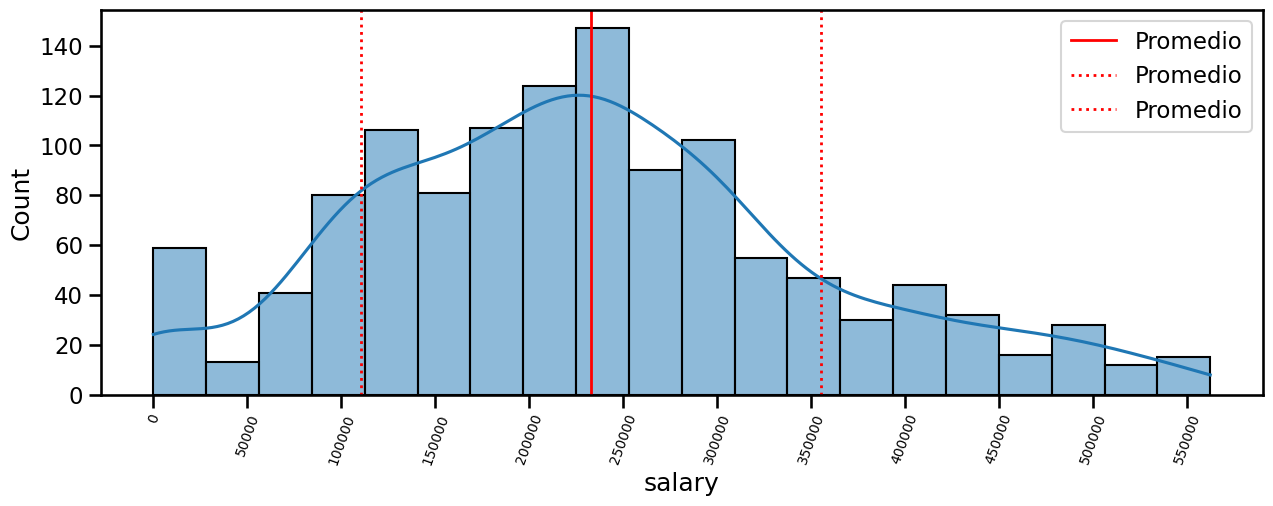

In [78]:
fig2, ax2 = plt.subplots(figsize=(15, 5))

mean = df_lang_sal_expand[cond3]['salary'].mean()
std = df_lang_sal_expand[cond3]['salary'].std()

sns.histplot(df_lang_sal_expand[cond3]['salary'],bins = 20 , kde = True, ax=ax2)

plt.axvline(mean, color='red', linestyle='solid', linewidth=2, label='Promedio')
plt.axvline(mean - std, color='red', linestyle=':', linewidth=2, label='Promedio')
plt.axvline(mean + std, color='red', linestyle=':', linewidth=2, label='Promedio')

plt.xticks(range(int(df_lang_sal_expand[cond3]['salary'].min() - 1), int(df_lang_sal_expand[cond3]['salary'].max() + 1), 50000), rotation = 70, fontsize = 10)
plt.legend()
plt.show()


In [99]:
def dist_men_std(df, lang):

    colores = sns.color_palette('bright', n_colors=len(lang) + 1)

    plt.subplots_adjust(hspace=0.5)

    for i,lan in enumerate(lang):

        cond = df['programming_language'] == lan

        mean = df[cond]['salary'].mean()
        std = df[cond]['salary'].std()

        plt.figure(figsize=(15,5))

        sns.histplot(df[cond]['salary'],bins = 30 , kde = True, color=colores[i+1], alpha=0.5)

        plt.axvline(mean, color=colores[i], linestyle='solid', linewidth=2, label='Mean')
        plt.axvline(mean - std, color=colores[i], linestyle=':', linewidth=2, label='Mean - std')
        plt.axvline(mean + std, color=colores[i], linestyle=':', linewidth=2, label='Mean + std')
        plt.title(lan)

    plt.xticks(range(int(df[cond]['salary'].min() - 1), int(df[cond]['salary'].max() + 1), 50000), rotation = 70, fontsize = 10)
    plt.legend()
    plt.show()

<Figure size 640x480 with 0 Axes>

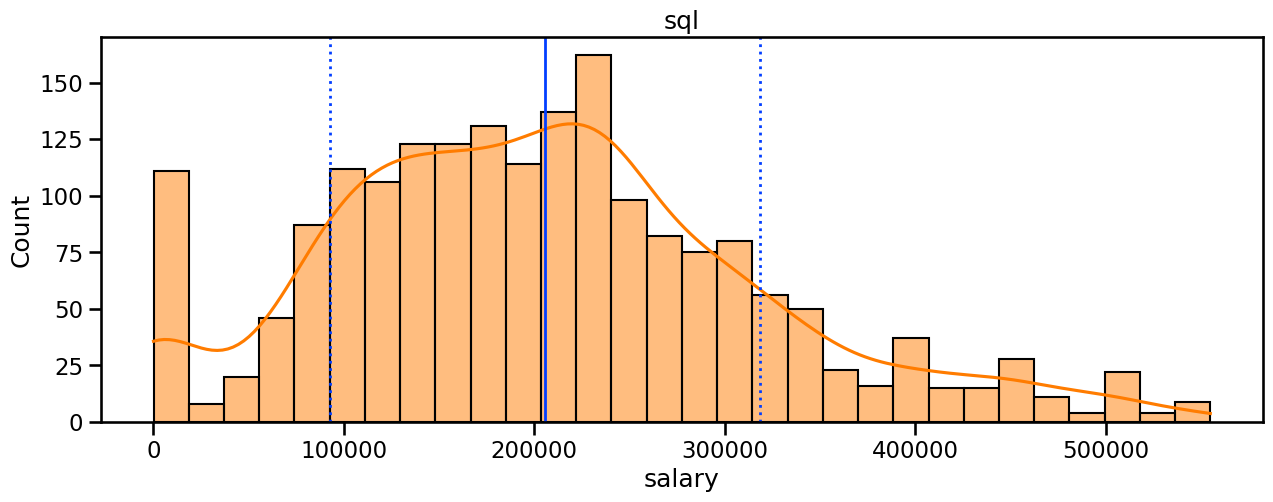

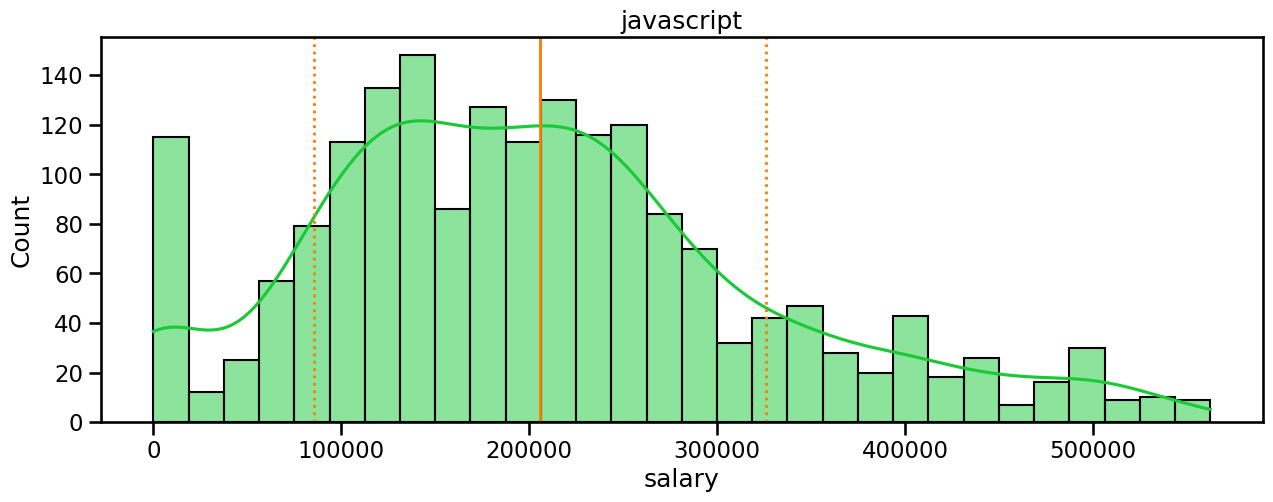

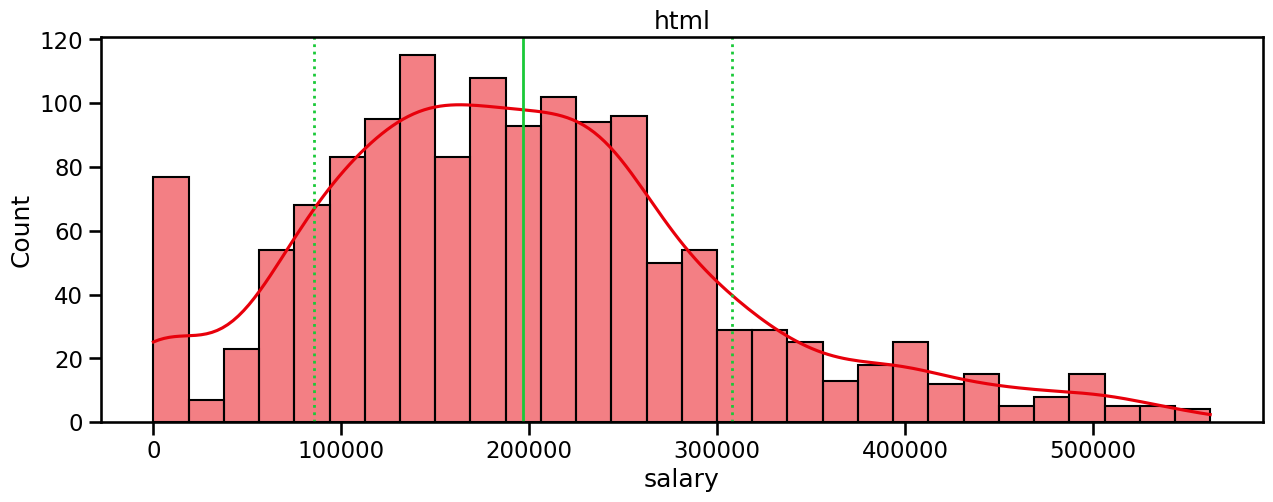

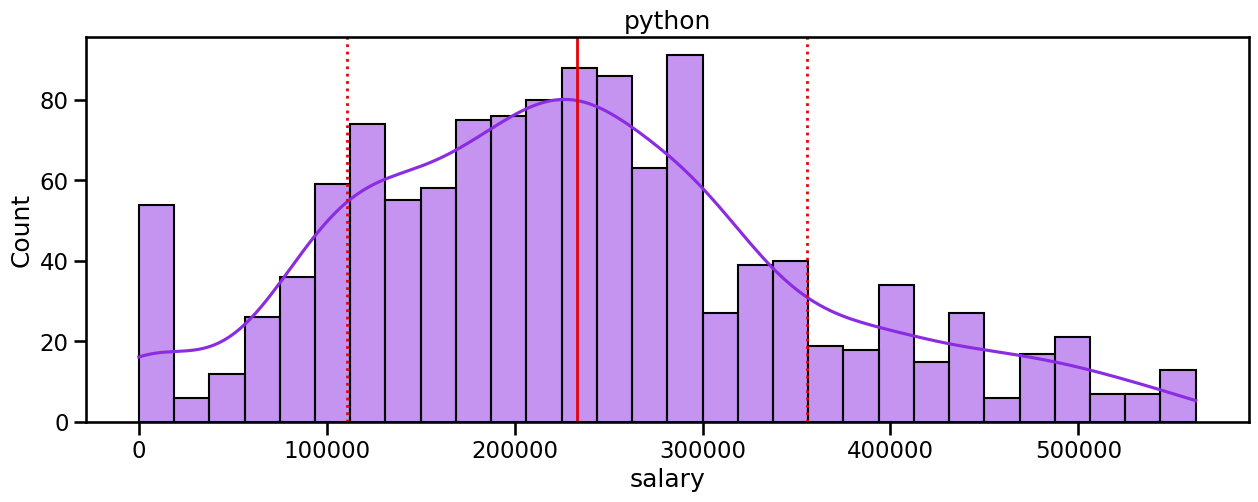

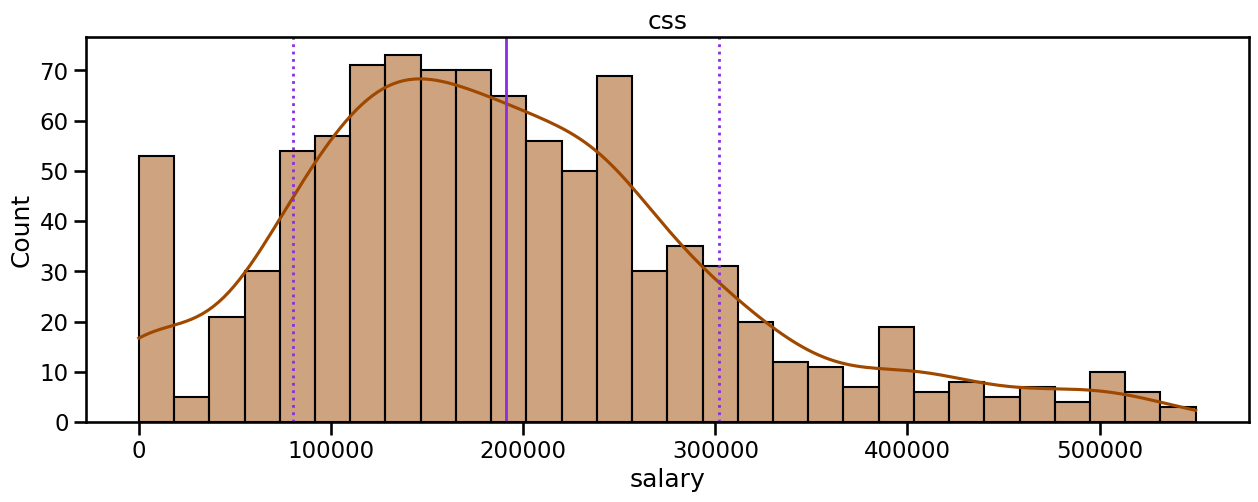

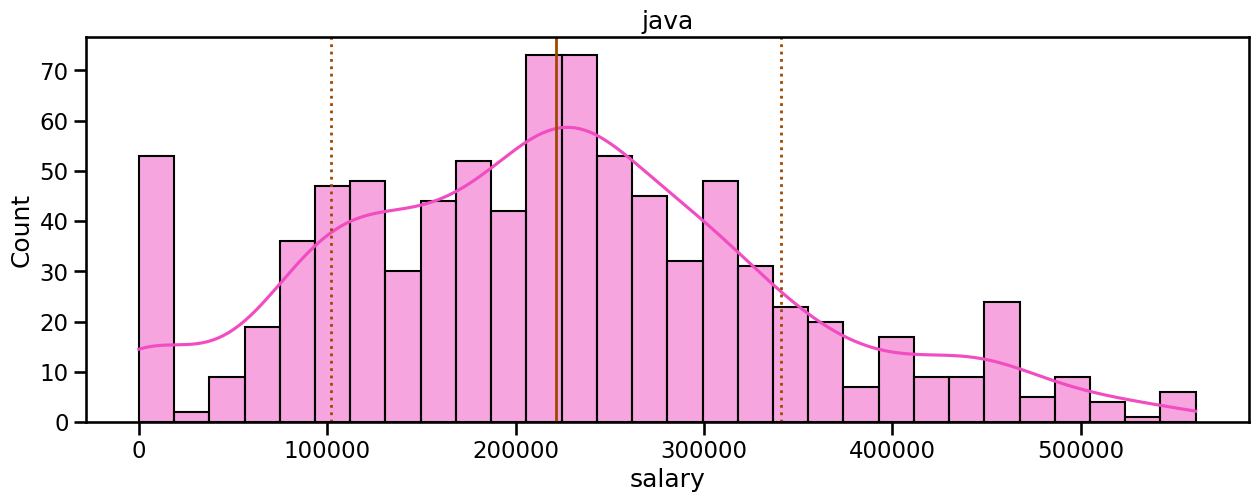

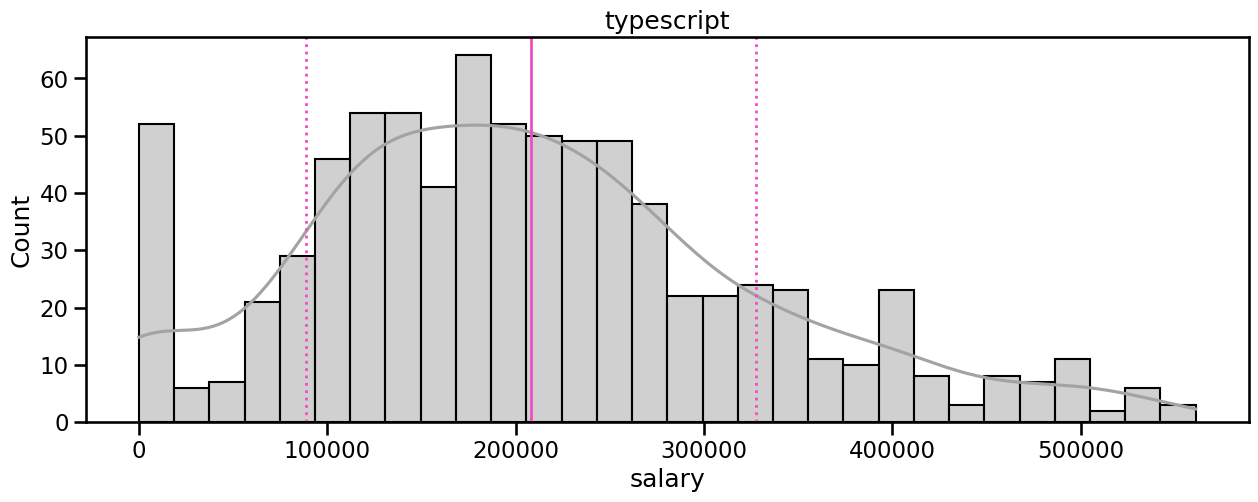

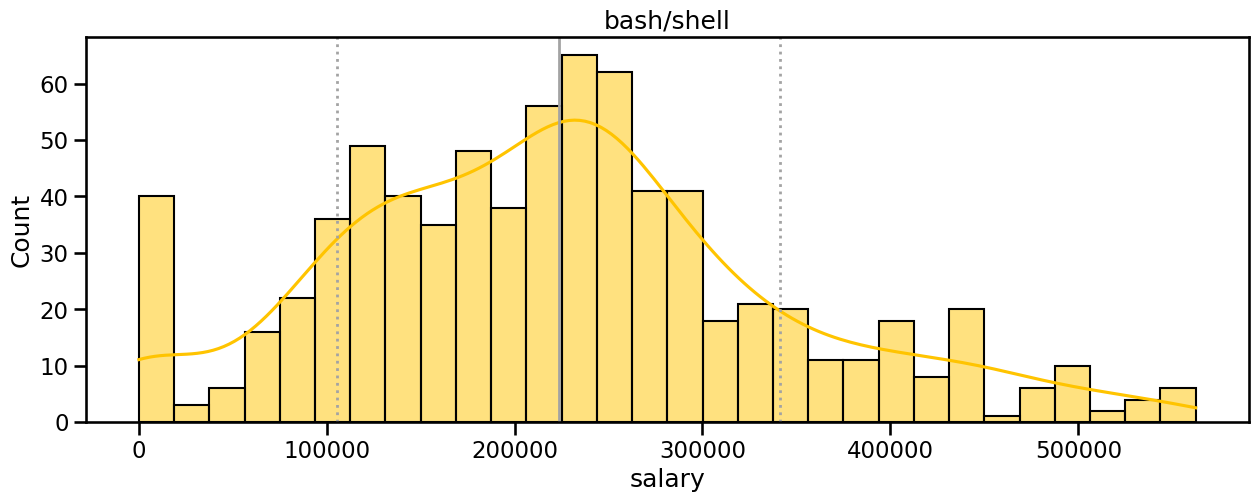

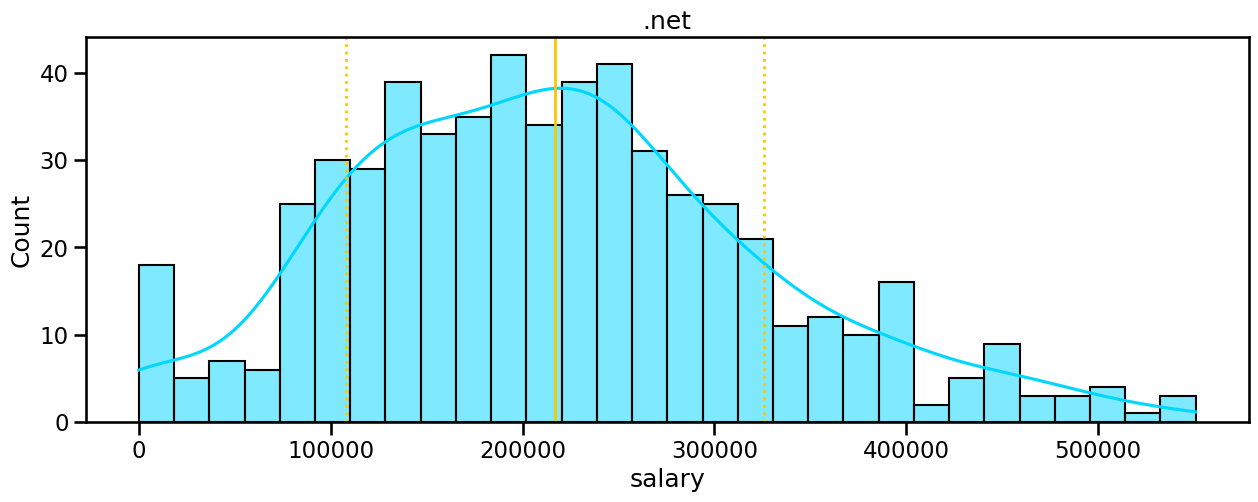

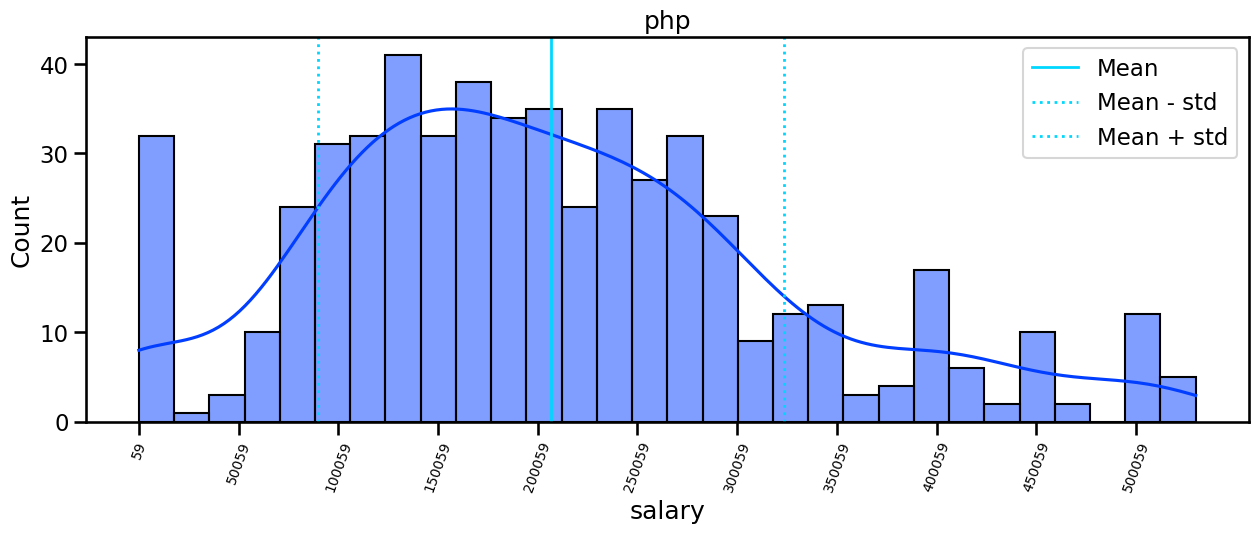

In [100]:
dist_men_std(df_lang_sal_expand, language)

## Filtrado de lenguajes relevantes

El siguiente código permite seleccionar sólo las filas donde el valor de la columna `programming_language` se encuentre en la lista `interesting_languages`.

In [51]:
# Filter out languages that we want to exclude
# Complete here with your selected list.
interesting_languages = ["python"]
filtered_df_lang = df_lang_sal[df_lang_sal.programming_language.isin(interesting_languages)]
filtered_df_lang[:5]

,programming_language,salary
0,python,245000.0
2,python,115000.0
15,python,317000.0
18,python,45000.0
19,python,200000.0


# Ejercicio 2 - Densidades y varias variables

Responder a la pregunta general: **¿Que herramientas (prácticas y teóricas) són útiles para explorar la base, descubrir patrones, asociaciones?**

Para ello considere (igual al ejercicio Anterior):
1. Seleccionar las columnas relevantes para analizar.
2. Seleccionar las filas relevantes para analizar. Esto incluye la eliminación de valores extremos y erróneos, pero también puede enfocar el análisis en sub-poblaciones. 

## a) Densidad conjunta

Que herramientas visuales y modelos puede utilizar para estudiar la distribución y comportamiento de sus datos? 

Elija tres variables numéricas y 2 variables categóricas. Visualice la base según varias de las variables elegidas. Puede describir de alguna forma el comportamiento de sus datos? Que herramientas utilizaría? Describa




## b) Asociación

* Necesitamos decidir si sacar o no la columna de salario bruto. Para hacer la encuesta más simple.
¿Existe una correlación entre el salario bruto y el neto? Que abordaje y medidas usaría



## c) Densidad condicional 

Estudie la distribución del salario según el nivel de estudio.

Separe la población según el nivel de estudio (elija dos subpoblaciones numerosas) y grafique de manera comparativa ambos histogramas de la variable `'salary_monthly_NETO'`
¿Considera que ambas variables son independientes?
¿Qué analizaría al respecto?

Calcule medidas de centralización y dispersión para cada subpoblación






## d) Densidad Conjunta condicional

Elija dos variables numéricas y una categórica. 
Estudie la dispersión (scatterplot) de las dos variables discriminando en color por la variable categórica (ayuda: hue en seaborn)
